In [201]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score

In [39]:
X, y = make_regression(n_samples=1000, n_features=5, n_informative=1, n_targets=1, noise=80, random_state=1)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [42]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr.coef_, lr.intercept_

(array([73.2452414 ,  0.10153222,  0.13790643, -4.98292577, -5.01124395]),
 np.float64(-3.1687898829739685))

<Axes: >

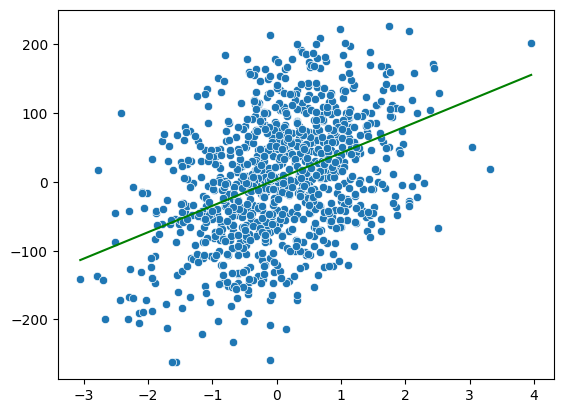

In [9]:
sns.scatterplot(x=X.ravel(), y=y)
sns.lineplot(x=X.ravel(),y=lr.predict(X), color = 'green')

# Batch Gradient Descent

In [ ]:
class GDRegressor:
    def __init__(self, learning_rate, epochs):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.epochs = epochs
    
    def fit(self, X, y):

        self.intercept_ = 0
        self.coef_ = np.ones(X.shape[1]) 

        for i in range(self.epochs):
            y_pred = self.intercept_ + np.dot(X, self.coef_)
            self.intercept_ = self.intercept_ - (self.learning_rate * (-2* np.mean(y - y_pred)))
            self.coef_ = self.coef_ - (self.learning_rate * (-2 * np.dot(( y - y_pred ), X))/X.shape[0])
            
    def predict(self, X_test):
        return self.intercept_ + np.dot(X_test, self.coef_)

In [80]:
MyGD = GDRegressor(0.15, 25)

MyGD.fit(X_train, y_train)

MyGD.coef_, MyGD.intercept_

(array([73.22620802,  0.1048401 ,  0.13155394, -4.97729353, -5.01412023]),
 np.float64(-3.1674888041986207))

In [85]:
y_pred_GD = MyGD.predict(X_test)
y_pred_LR = lr.predict(X_test)

error = (np.sum((y_pred_GD - y_pred_LR)**2))
# error
print(f"R2 Score of Linear Regressor : {r2_score(y_test, y_pred_LR)}")
print(f"R2 Score of Gradient Descent Regressor : {r2_score(y_test, y_pred_GD)}")

R2 Score of Linear Regressor : 0.44489533098980205
R2 Score of Gradient Descent Regressor : 0.44487297473854315


# Stochastic Gradient Descent

In [ ]:
class SGDRegressor:
    def __init__(self, learning_rate, epochs):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.epochs = epochs
    
    def fit(self, X, y):

        self.intercept_ = 0
        self.coef_ = np.ones(X.shape[1]) 

        for i in range(self.epochs):
            for j in range(X_train.shape[0]):
                
                idx = np.random.randint(0, X.shape[0])

                y_pred = self.intercept_ + np.dot(X[idx], self.coef_)

                self.intercept_ = self.intercept_ - (self.learning_rate * -2 * (y[idx] - y_pred))

                self.coef_ = self.coef_ - (self.learning_rate * -2 * np.dot(( y[idx] - y_pred ), X[idx]))
            
    def predict(self, X_test):
        return self.intercept_ + np.dot(X_test, self.coef_)

In [177]:
sgd = SGDRegressor(learning_rate=0.001, epochs=35)

sgd.fit(X_train, y_train)

sgd.coef_, sgd.intercept_

(array([74.39131215, -0.99895004,  2.28619174, -4.66403818, -4.96105547]),
 np.float64(-2.4841577784772397))

In [178]:
y_pred = sgd.predict(X_test)

r2_score(y_test,y_pred)

0.4499469650001604

In [181]:
bgd = GDRegressor(learning_rate=0.001, epochs=1000)

bgd.fit(X_train, y_train)

y_pred = bgd.predict(X_test)

r2_score(y_test,y_pred)

0.42471318786839307

# Mini Batch Gradient Descent

In [ ]:
class MBGDRegressor:
    def __init__(self, learning_rate: float, epochs:int, batch_size: int):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batchs_size = batch_size
    
    def fit(self, X_train, y_train):

        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):

            total_batches = int(X_train.shape[0]/self.batchs_size)

            for j in range(total_batches):

                idx = random.sample(range(X_train.shape[0]), self.batchs_size)

                y_pred = np.dot(X_train[idx], self.coef_) + self.intercept_

                self.coef_ = self.coef_ - self.learning_rate * (-2 * np.dot((y_train[idx] - y_pred), X_train[idx]))

                self.intercept_ = self.intercept_ - self.learning_rate * (-2 * np.mean(y_train[idx] - y_pred))
                
        self.print(self.intercept_, self.coef_)

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [ ]:
mbgd = MBGDRegressor(learning_rate=0.01, epochs=10, batch_size=X_train.shape[0]/10)

mbgd.fit(X_train, y_train) 

[1. 1. 1. 1. 1.] 0


In [211]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(learning_rate='constant', eta0=0.02)

epochs = 50
batch_size = 80

for i in range(epochs):

    idx = random.sample(range(X_train.shape[0]), batch_size)
    sgd.partial_fit(X_train[idx], y_train[idx])

sgd.coef_, sgd.intercept_
r2_score(y_test, sgd.predict(X_test))

0.41611994473936376